## Portfolio Optimization

In [1]:
import numpy as np
from scipy.optimize import minimize

# Given data
sigma_X = np.sqrt(0.81)  # Standard deviation of X
sigma_Y = np.sqrt(0.49)  # Standard deviation of Y
sigma_Z = np.sqrt(0.64)  # Standard deviation of Z
rho_XY = 0.6  # Correlation between X and Y
rho_XZ = 0.6  # Correlation between X and Z
rho_YZ = 0.6  # Correlation between Y and Z
w_X = 150  # Weight of X
w_Z = -50  # Weight of Z

# Covariance calculations
cov_XY = rho_XY * sigma_X * sigma_Y
cov_XZ = rho_XZ * sigma_X * sigma_Z
cov_YZ = rho_YZ * sigma_Y * sigma_Z

# Function to calculate portfolio variance
def portfolio_variance(w_Y):
    return (w_X**2 * sigma_X**2 + w_Y**2 * sigma_Y**2 + w_Z**2 * sigma_Z**2 +
            2 * w_X * w_Y * cov_XY + 2 * w_X * w_Z * cov_XZ + 2 * w_Y * w_Z * cov_YZ)

# Use scipy's minimize function to find the optimal weight for Y
result = minimize(portfolio_variance, 0)  # Start with an initial guess of 0 for w_Y
optimal_w_Y = result.x[0]

# Output the result
print(f"The optimal weight for Y to minimize portfolio risk is: {optimal_w_Y}")

The optimal weight for Y to minimize portfolio risk is: -81.42852707974468


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Load the Excel file
file_path = '/Users/evelyndu/Dropbox/24-5 Master Study/RA/Updates/crypto_stock_data.xlsx'
xls = pd.ExcelFile(file_path)

# Define the regression function
def run_jump_diffusion_regression(df, symbol):
    # Compute the log of trading volume as 'jump'
    df['Log Volume'] = np.log(df['Volume'])

    # Calculate the moving average and standard deviation of log returns over the last 10 days
    df['Mu'] = df['Log Return'].rolling(window=10).mean()
    df['Sigma'] = df['Log Return'].rolling(window=10).std()

    # Drop rows with missing values due to rolling operations
    df_clean = df.dropna(subset=['Mu', 'Sigma', 'Log Volume', 'Log Return'])

    # Prepare the regression model
    X = df_clean[['Mu', 'Sigma', 'Log Volume']]  # Independent variables
    X = sm.add_constant(X)  # Add intercept term
    y = df_clean['Log Return']  # Dependent variable

    # Fit the linear regression model
    model = sm.OLS(y, X).fit()

    # Record the results
    results = {
        'Currency': symbol,
        'Intercept': model.params['const'],
        'Intercept t-stat': model.tvalues['const'],
        'Mu Coefficient': model.params['Mu'],
        'Mu t-stat': model.tvalues['Mu'],
        'Sigma Coefficient': model.params['Sigma'],
        'Sigma t-stat': model.tvalues['Sigma'],
        'Log Volume Coefficient': model.params['Log Volume'],
        'Log Volume t-stat': model.tvalues['Log Volume'],
        'Adjusted R2': model.rsquared_adj,
        'Number of Observations': len(df_clean)
    }

    return results

# Initialize a list to store all results
all_results = []

# Process each sheet in the Excel file
for sheet_name in xls.sheet_names:
    df_clean = pd.read_excel(xls, sheet_name=sheet_name, header=2)
    
    # Rename the columns for easier analysis
    df_clean.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
    
    # Calculate log returns for the cryptocurrency
    df_clean['Log Return'] = (df_clean['Close'].pct_change() + 1).apply(np.log)

    # Run the regression for each cryptocurrency
    results = run_jump_diffusion_regression(df_clean, sheet_name)
    all_results.append(results)

    # Print a message every 50 currencies
    if len(all_results) % 50 == 0:
        print(f"{len(all_results)} records have been saved.")

# Convert the results into a DataFrame
results_df = pd.DataFrame(all_results)

# Specify the output file path
output_file_path = '/Users/evelyndu/Dropbox/24-5 Master Study/RA/Updates/crypto_regression_results.xlsx'

# Save the results to the specified file
results_df.to_excel(output_file_path, index=False)

# Final message after all records are saved
print(f"Total {len(all_results)} records have been saved.")

## Sharpe Ratio

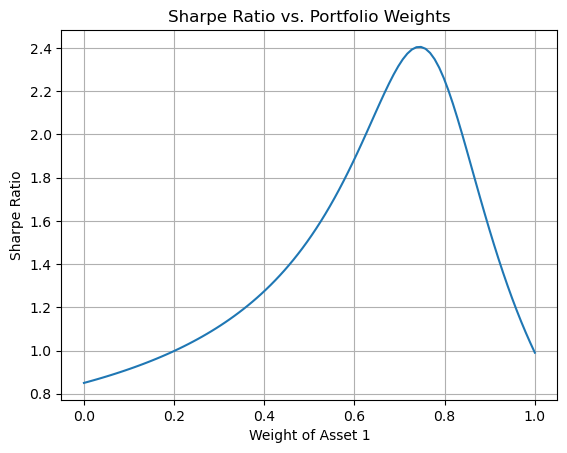

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Assume we have 2 assets
mu = np.array([0.1, 0.2])  # expected returns
Sigma = np.array([[0.005, -0.010],
                  [-0.010, 0.040]])  # covariance matrix
rf = 0.03  # risk-free rate

def sharpe_ratio(w):
    w = np.array(w)
    port_return = w @ mu
    port_vol = np.sqrt(w @ Sigma @ w)
    return (port_return - rf) / port_vol

# Vary weights (w1, w2), subject to w1 + w2 = 1 and w1 >= 0, w2 >= 0
w1_vals = np.linspace(0, 1, 100)
sharpe_vals = [sharpe_ratio([w1, 1 - w1]) for w1 in w1_vals]

plt.plot(w1_vals, sharpe_vals)
plt.xlabel("Weight of Asset 1")
plt.ylabel("Sharpe Ratio")
plt.title("Sharpe Ratio vs. Portfolio Weights")
plt.grid(True)
plt.show()

### Interpretation for Concave

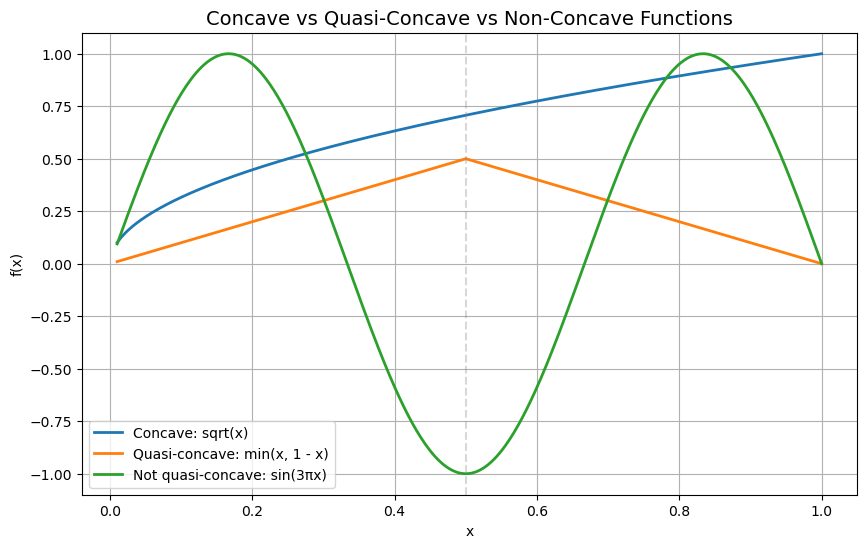

In [7]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.01, 1, 500)

# Concave function
f1 = np.sqrt(x)

# Quasi-concave but not concave (peak at x=0.5)
f2 = np.minimum(x, 1 - x)

# Neither concave nor quasi-concave
f3 = np.sin(3 * np.pi * x)

# Plot
plt.figure(figsize=(10, 6))

plt.plot(x, f1, label='Concave: sqrt(x)', linewidth=2)
plt.plot(x, f2, label='Quasi-concave: min(x, 1 - x)', linewidth=2)
plt.plot(x, f3, label='Not quasi-concave: sin(3πx)', linewidth=2)

plt.axvline(0.5, color='gray', linestyle='--', alpha=0.3)
plt.title("Concave vs Quasi-Concave vs Non-Concave Functions", fontsize=14)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

### Concave for Sharpe Ratio

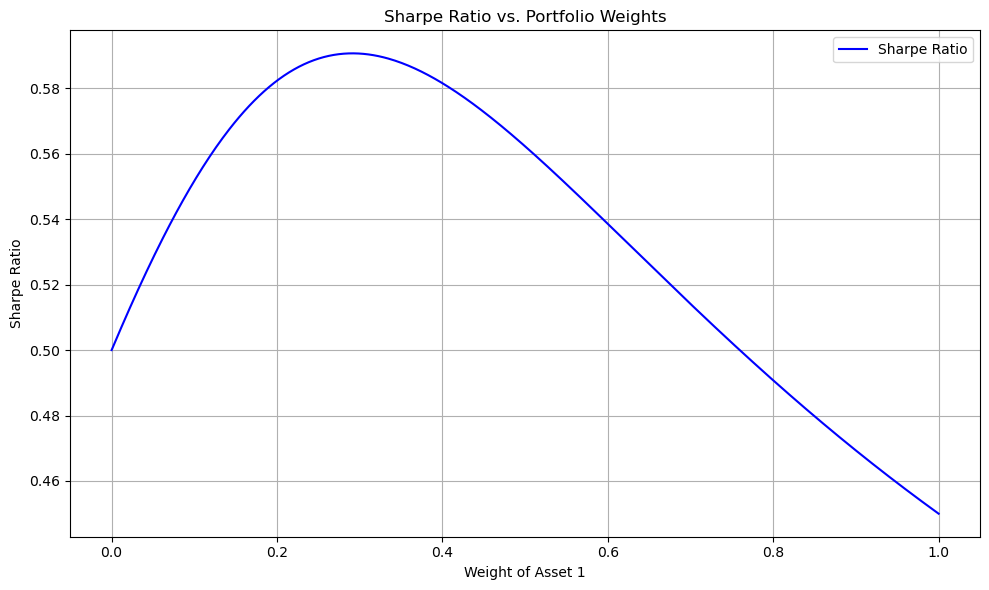

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Define expected returns and covariance matrix for a simple 2-asset portfolio
mu = np.array([0.12, 0.08])       # Expected returns for asset 1 and 2
Sigma = np.array([[0.04, 0.006],
                  [0.006, 0.01]])  # Covariance matrix
rf = 0.03  # Risk-free rate

# Generate weight combinations for asset 1 (asset 2 is 1 - w1)
w1_vals = np.linspace(0, 1, 500)
sharpe_ratios = []

for w1 in w1_vals:
    w = np.array([w1, 1 - w1])
    port_return = w @ mu
    port_variance = w @ Sigma @ w
    port_std = np.sqrt(port_variance)
    sharpe = (port_return - rf) / port_std
    sharpe_ratios.append(sharpe)

# Plot Sharpe Ratio vs. Weight of Asset 1
plt.figure(figsize=(10, 6))
plt.plot(w1_vals, sharpe_ratios, label="Sharpe Ratio", color="blue")
plt.xlabel("Weight of Asset 1")
plt.ylabel("Sharpe Ratio")
plt.title("Sharpe Ratio vs. Portfolio Weights")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()